# Devnagari Digit Classification — Fully Connected Network (FCN)

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Extract Dataset

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI ML-LastSem/Week4/Copy of Copy of devnagari digit.zip"
extract_to = "/content/devnagari_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted! Contents:")
print(os.listdir(extract_to))

Extracted! Contents:
['DevanagariHandwrittenDigitDataset']


## Task 1: Data Preparation

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from keras.utils import to_categorical

DATASET_ROOT = "/content/devnagari_data/DevanagariHandwrittenDigitDataset"

TRAIN_DIR = os.path.join(DATASET_ROOT, "Train")
TEST_DIR  = os.path.join(DATASET_ROOT, "Test")

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

class_names = sorted(os.listdir(TRAIN_DIR))
class_map   = {name: i for i, name in enumerate(class_names)}
print("Class map:", class_map)

def load_images_from_folder(folder, class_map):
    """Load all images from folder using a fixed class_map for consistent labels."""
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder)):
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        if class_name not in class_map:
            print(f"Warning: class '{class_name}' not in class_map, skipping.")
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            img = Image.open(img_path).convert("L")          # grayscale
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))         # resize to 28x28
            img = np.array(img) / 255.0                       # normalize to [0, 1]
            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)


X_train, y_train = load_images_from_folder(TRAIN_DIR, class_map)
X_test,  y_test  = load_images_from_folder(TEST_DIR,  class_map)

print(f"Train: {X_train.shape}, labels: {y_train.shape}")
print(f"Test:  {X_test.shape},  labels: {y_test.shape}")
print(f"Unique train labels: {np.unique(y_train)}")
print(f"Unique test  labels: {np.unique(y_test)}")

Class map: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Train: (17000, 28, 28), labels: (17000,)
Test:  (3000, 28, 28),  labels: (3000,)
Unique train labels: [0 1 2 3 4 5 6 7 8 9]
Unique test  labels: [0 1 2 3 4 5 6 7 8 9]


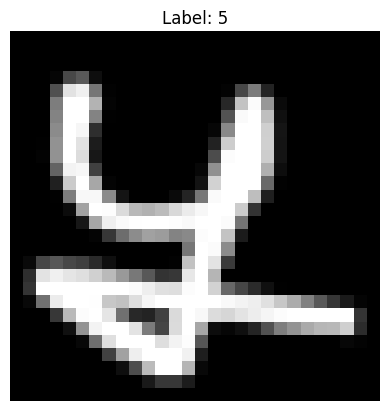

In [ ]:
# Preview a sample image
plt.imshow(X_train[10000], cmap='gray')
plt.title(f"Label: {y_train[10000]}")
plt.axis('off')
plt.show()

## Task 2: Build the FCN Model

In [ ]:
import keras
from keras import Sequential
from keras.layers import Input, Flatten, Dense

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(64,  activation='sigmoid'),   # Hidden layer 1
    Dense(128, activation='sigmoid'),   # Hidden layer 2
    Dense(256, activation='sigmoid'),   # Hidden layer 3
    Dense(10,  activation='softmax'),   # Output layer
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Task 4: Train the Model

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2920 - loss: 1.9739
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4918 - loss: 1.6033 - val_accuracy: 0.0000e+00 - val_loss: 7.2951
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8286 - loss: 0.5896
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8567 - loss: 0.4834 - val_accuracy: 0.0000e+00 - val_loss: 8.8343
Epoch 3/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9214 - loss: 0.2982
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9279 - loss: 0.2672 - val_accuracy: 0.0000e+00 - val_loss: 9.3340
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9426 - loss: 0.1965
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9473 - loss: 0.1870 - val_accuracy: 0.0000e+00 - val_loss: 9.5917
Epoch 5/20
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 

## Visualization: Training and Validation Loss & Accuracy

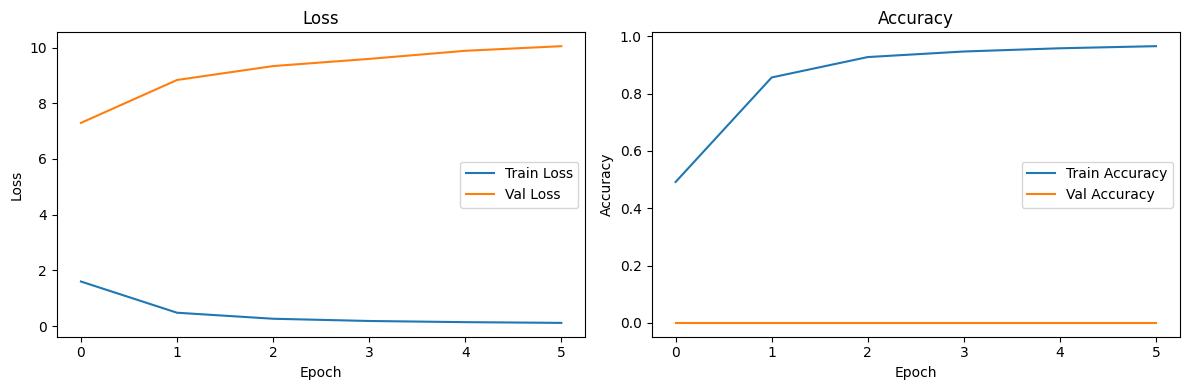

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history.history['loss'],     label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy
ax2.plot(history.history['accuracy'],     label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model on Test Set

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:{test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss:2.0711
Test Accuracy: 0.6330


## Task 6: Save and Load the Model

In [ ]:
# Save
model.save('devnagari_fcn_model.h5')
print("Model saved to devnagari_fcn_model.h5")

# Load
from keras.models import load_model
loaded_model = load_model('devnagari_fcn_model.h5')
print("Model loaded successfully.")

Model saved to devnagari_fcn_model.h5
Model loaded successfully.


## Task 7: Predictions

In [ ]:
# Predictions on full test set
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

print(f"First 10 predicted labels: {y_pred[:10]}")
print(f"First 10 true labels:      {y_test[:10]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels:      [0 0 0 0 0 0 0 0 0 0]


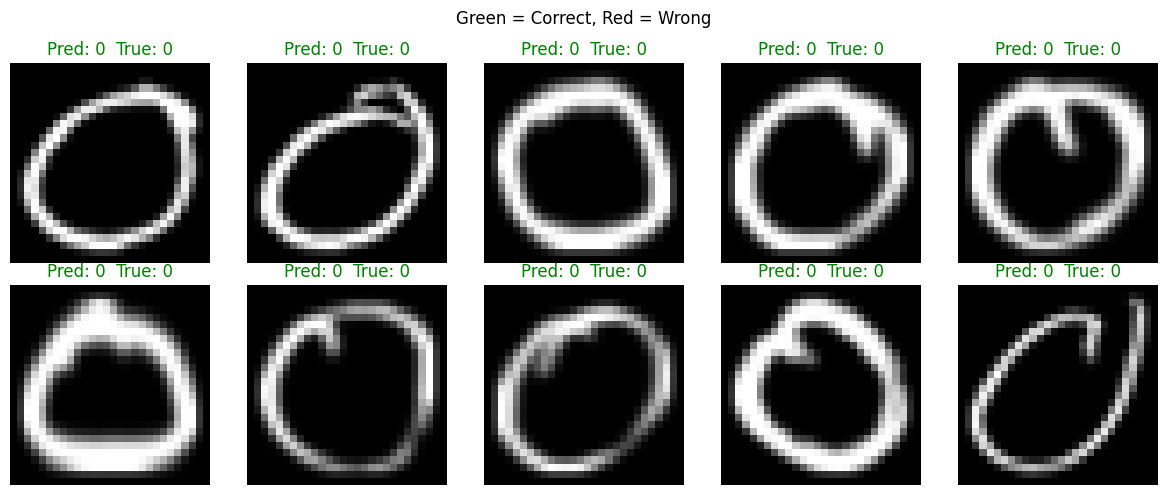

In [ ]:
# Visualize a few predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    ax.set_title(f"Pred: {y_pred[i]}  True: {y_test[i]}", color=color)
    ax.axis('off')
plt.suptitle('Green = Correct, Red = Wrong')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted label for test image 1: 0
True label:                         0


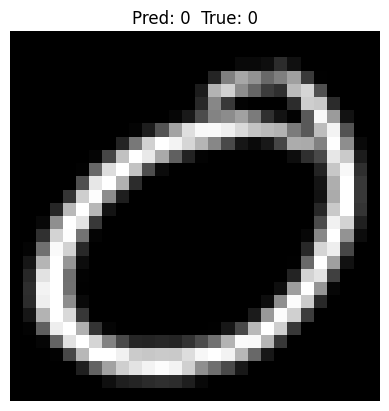

In [ ]:
# Single-image prediction example
idx = 1
pred = model.predict(X_test[idx].reshape(1, 28, 28)).argmax(axis=1)
print(f"Predicted label for test image {idx}: {pred[0]}")
print(f"True label:                         {y_test[idx]}")

plt.imshow(X_test[idx], cmap='gray')
plt.title(f"Pred: {pred[0]}  True: {y_test[idx]}")
plt.axis('off')
plt.show()